Inicio del procesamiento de metadatos clínicos...
--------------------------------------------------
Se identificaron 640 archivos. Procediendo con la extracción de datos...

--- ESTADÍSTICAS DESCRIPTIVAS (MUESTRA TOTAL) ---
        count    mean    std    min     25%     50%     75%    max
Edad    640.0   57.99  13.93   16.0   49.00   60.00   68.00   90.0
Peso    640.0   63.19  11.82   34.1   54.84   62.05   70.21  112.8
Altura  640.0  162.92   8.73  140.2  156.40  162.60  169.70  186.6

--- DISTRIBUCIÓN DE LA VARIABLE CATEGÓRICA SEXO ---
Sexo
M    357
F    283
Name: count, dtype: int64

--- ESTADÍSTICAS DESCRIPTIVAS ESTRATIFICADAS POR SEXO ---


Sexo               F       M
Edad   count  283.00  357.00
       mean    56.07   59.52
       std     14.48   13.31
       min     18.00   16.00
       25%     46.00   53.00
       50%     56.00   62.00
       75%     67.50   68.00
       max     90.00   85.00
Peso   count  283.00  357.00
       mean    58.07   67.25
       std     10.89   10.94
       min     34.10   38.50
       25%     51.10   60.00
       50%     56.00   66.10
       75%     63.20   72.80
       max    103.20  112.80
Altura count  283.00  357.00
       mean   156.02  168.39
       std      6.03    6.35
       min    140.20  152.20
       25%    152.05  164.20
       50%    155.90  168.50
       75%    160.30  173.00
       max    173.00  186.60

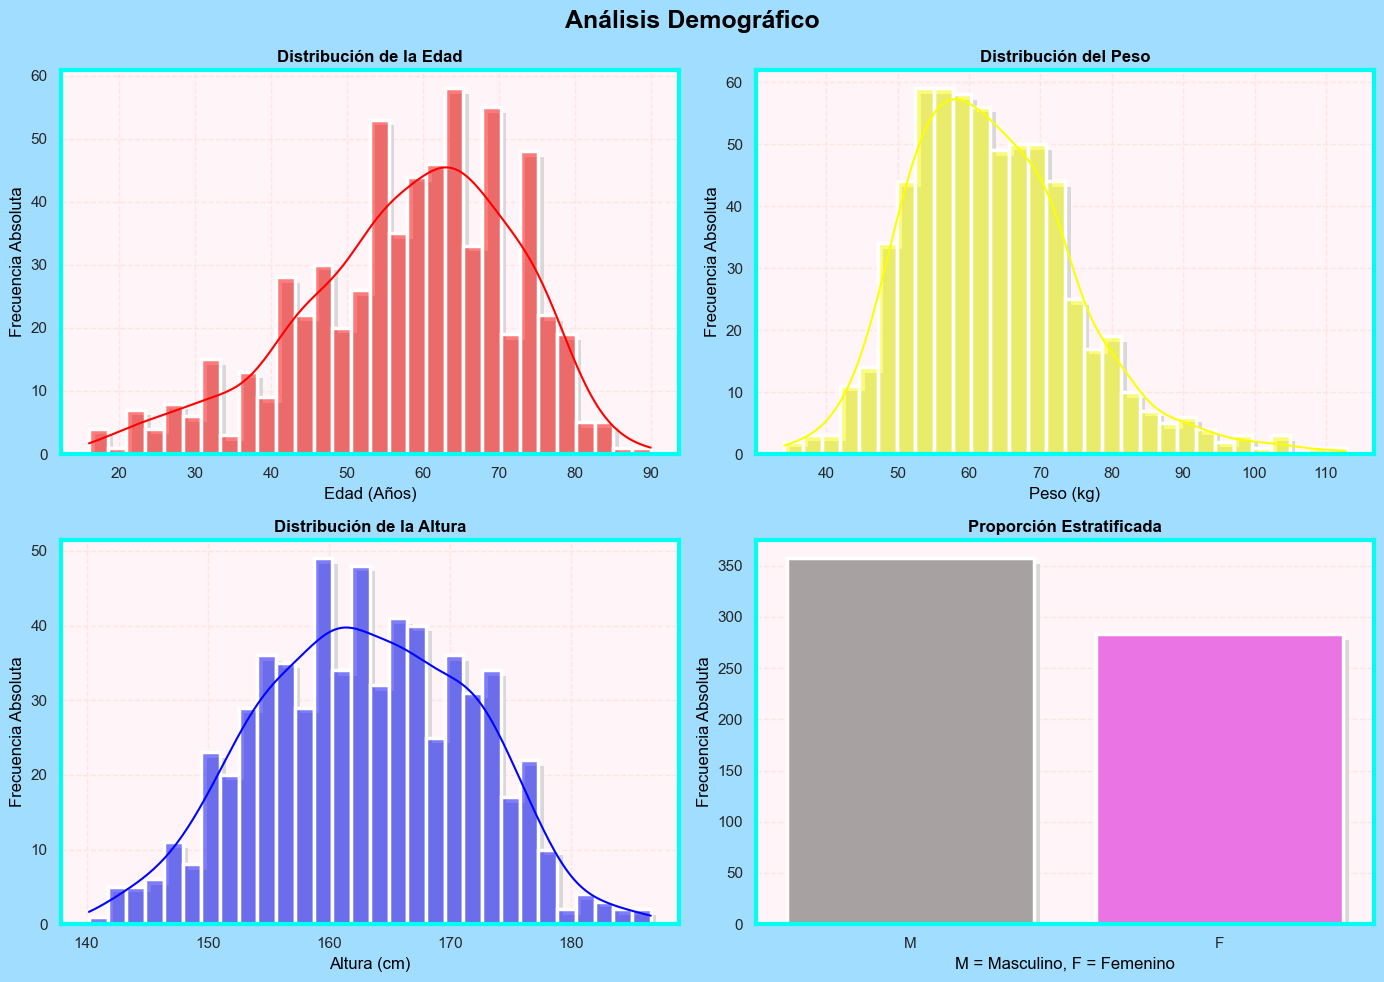

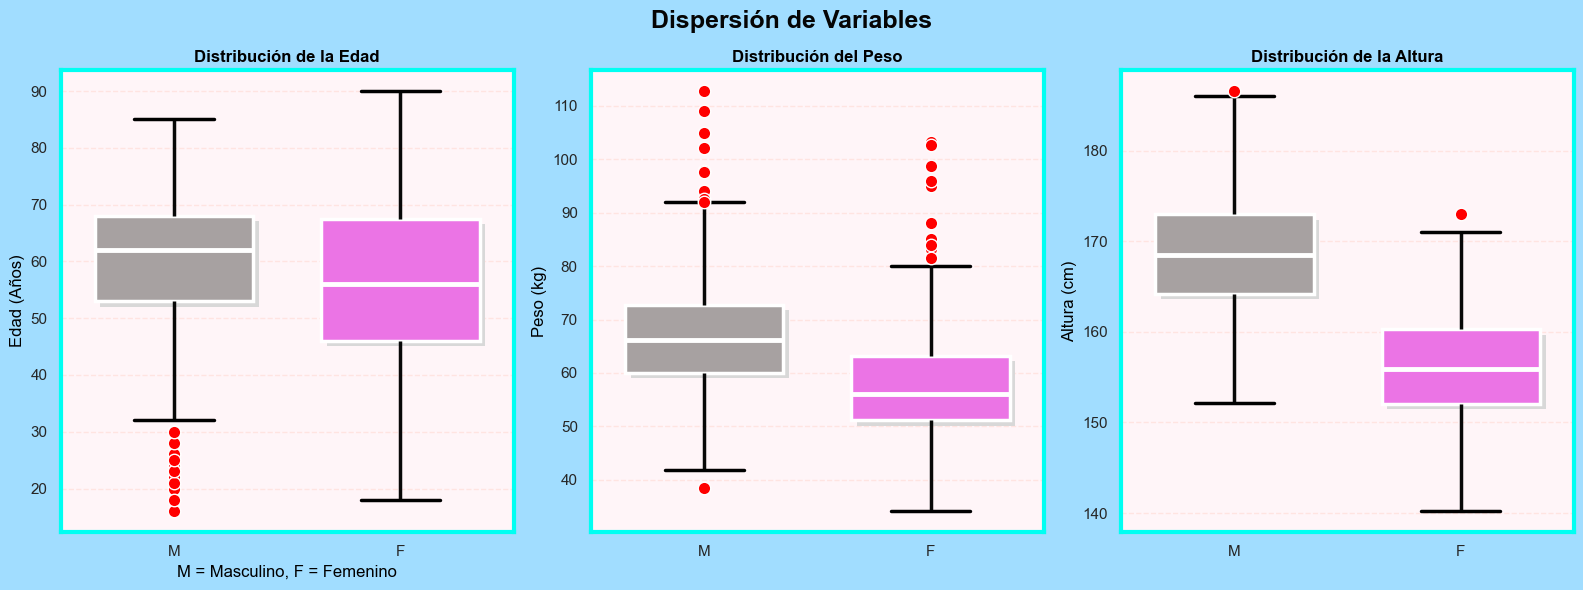

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as path_effects
from pathlib import Path
from IPython.display import display

print("Inicio del procesamiento de metadatos clínicos...\n" + "-"*50)

# Definición de la ruta de acceso al directorio de datos crudos.
carpeta_crudos = Path.home() / 'Desktop' / 'Datos crudos'

if not carpeta_crudos.exists():
    print("Error: El directorio 'Datos crudos' no fue localizado en la ruta especificada.")
else:
    datos_pacientes = []
    
    # Iteración sobre los archivos con formato CSV correspondientes a los registros de pacientes.
    archivos_csv = list(carpeta_crudos.glob('Paciente_*.csv'))
    print(f"Se identificaron {len(archivos_csv)} archivos. Procediendo con la extracción de datos...")
    
    for archivo in archivos_csv:
        try:
            # Lectura exclusiva de la primera fila del archivo CSV.
            df_temp = pd.read_csv(archivo, nrows=1)
            
            if not df_temp.empty:
                # Extracción del identificador único del paciente a partir de la nomenclatura del archivo.
                id_paciente = archivo.stem.split('_')[1]
                
                datos_pacientes.append({
                    'ID': id_paciente,
                    'Edad': df_temp['Edad'].iloc[0],
                    'Peso': df_temp['Peso'].iloc[0],
                    'Altura': df_temp['Altura'].iloc[0],
                    'Sexo': df_temp['Sexo'].iloc[0]
                })
        except Exception as error:
            print(f"Excepción ocurrida durante la lectura del archivo {archivo.name}: {error}")
            
    # Consolidación de los registros extraídos en un marco de datos (DataFrame) estructurado.
    df_demografia = pd.DataFrame(datos_pacientes)
    
    if not df_demografia.empty:
        # Generación y visualización de estadísticas descriptivas.
        print("\n--- ESTADÍSTICAS DESCRIPTIVAS (MUESTRA TOTAL) ---")
        # La función .T transpone la tabla para presentar una estructura vertical y angosta.
        print(df_demografia[['Edad', 'Peso', 'Altura']].describe().round(2).T)
        
        print("\n--- DISTRIBUCIÓN DE LA VARIABLE CATEGÓRICA SEXO ---")
        print(df_demografia['Sexo'].value_counts())
        
        print("\n--- ESTADÍSTICAS DESCRIPTIVAS ESTRATIFICADAS POR SEXO ---")
        # Se aplica la transposición (.T) para reducir la anchura de la salida, evitando recortes visuales.
        estadisticas_sexo = df_demografia.groupby('Sexo')[['Edad', 'Peso', 'Altura']].describe().round(2).T
        display(estadisticas_sexo)
        
        # Configuración de parámetros estéticos para proveer una apariencia afable y cálida.
        sns.set_theme(
            style="whitegrid",
            rc={
                "axes.facecolor": "#FFF5F8",      # fondo interior
                "figure.facecolor": "#A1DDFF",    # fondo exterior
                "grid.color": "#FFE4E1",          # color de lacuadrícula
                "grid.linestyle": "--",           # Línea 
                "axes.edgecolor": "#00FFF2",      # Bordes 
                "axes.linewidth": 3.0             # Grosor de los bordes
            }
        )
        
        # Definición de paletas de colores armónicas y suaves.
        color_edad = "#FF0000"    
        color_peso = "#FBFF00"    
        color_altura = "#0004FF"  
        paleta_sexo = ["#A8A0A0", "#FF60F7"] 
        color_fuente = "#000000"  
        
        # Configuración del efecto de sombreado para generar relieve.
        # Se proyecta una sombra desplazada y translúcida detrás de cada elemento geométrico.
        efecto_relieve = [
            path_effects.SimplePatchShadow(offset=(4, -4), alpha=2.0, shadow_rgbFace="#D8D8D8"),
            path_effects.Normal()
        ]

        # ---------------------------------------------------------
        # FIGURA 1: DISTRIBUCIONES DE FRECUENCIA Y PROPORCIÓN
        # ---------------------------------------------------------
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Análisis Demográfico', fontsize=18, fontweight='bold', color="#000000")
        
        # Generación de histogramas.
        sns.histplot(data=df_demografia, x='Edad', bins=30, kde=True, ax=axes[0, 0], color=color_edad, edgecolor='white', linewidth=2.5)
        axes[0, 0].set_title('Distribución de la Edad', color=color_fuente, fontweight='bold')
        axes[0, 0].set_xlabel('Edad (Años)', color=color_fuente)
        axes[0, 0].set_ylabel('Frecuencia Absoluta', color=color_fuente)
        
        sns.histplot(data=df_demografia, x='Peso', bins=30, kde=True, ax=axes[0, 1], color=color_peso, edgecolor='white', linewidth=2.5)
        axes[0, 1].set_title('Distribución del Peso', color=color_fuente, fontweight='bold')
        axes[0, 1].set_xlabel('Peso (kg)', color=color_fuente)
        axes[0, 1].set_ylabel('Frecuencia Absoluta', color=color_fuente)
        
        sns.histplot(data=df_demografia, x='Altura', bins=30, kde=True, ax=axes[1, 0], color=color_altura, edgecolor='white', linewidth=2.5)
        axes[1, 0].set_title('Distribución de la Altura', color=color_fuente, fontweight='bold')
        axes[1, 0].set_xlabel('Altura (cm)', color=color_fuente)
        axes[1, 0].set_ylabel('Frecuencia Absoluta', color=color_fuente)
        
        # Gráfico de barras con ajuste de grosor para la proporción poblacional.
        sns.countplot(data=df_demografia, x='Sexo', hue='Sexo', ax=axes[1, 1], palette=paleta_sexo, order=['M', 'F'], legend=False, edgecolor='white', linewidth=2.5)
        axes[1, 1].set_title('Proporción Estratificada', color=color_fuente, fontweight='bold')
        axes[1, 1].set_xlabel('M = Masculino, F = Femenino', color=color_fuente)
        axes[1, 1].set_ylabel('Frecuencia Absoluta', color=color_fuente)
        
        # Aplicación iterativa del efecto de relieve a todos los rectángulos de los subgráficos.
        for ax in axes.flat:
            for patch in ax.patches:
                patch.set_path_effects(efecto_relieve)
        
        # Ajuste de la disposición espacial de los subgráficos.
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

        # ---------------------------------------------------------
        # FIGURA 2: GRÁFICOS DE CAJAS (MEDIDAS DE POSICIÓN Y DISPERSIÓN)
        # ---------------------------------------------------------
        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 6))
        fig2.suptitle('Dispersión de Variables', fontsize=18, fontweight='bold', color="#050505")
        
        # Configuración de propiedades visuales de las cajas. 
        
        propiedades_cajas = {
            'boxprops': {'edgecolor': 'white', 'linewidth': 2.5},
            'whiskerprops': {'color': "#080808", 'linewidth': 2.5},
            'capprops': {'color': "#000000", 'linewidth': 2.5},
            'medianprops': {'color': 'white', 'linewidth': 3.5},
            'flierprops': {'marker': 'o', 'markerfacecolor': "#FF0000", 'markeredgecolor': 'white', 'markersize': 9}
        }

        # Diagramas de caja y bigotes. .
        sns.boxplot(data=df_demografia, x='Sexo', y='Edad', hue='Sexo', ax=axes2[0], palette=paleta_sexo, order=['M', 'F'], legend=False, width=0.7, **propiedades_cajas)
        axes2[0].set_title('Distribución de la Edad', color=color_fuente, fontweight='bold')
        axes2[0].set_xlabel('M = Masculino, F = Femenino', color=color_fuente)
        axes2[0].set_ylabel('Edad (Años)', color=color_fuente)
        
        sns.boxplot(data=df_demografia, x='Sexo', y='Peso', hue='Sexo', ax=axes2[1], palette=paleta_sexo, order=['M', 'F'], legend=False, width=0.7, **propiedades_cajas)
        axes2[1].set_title('Distribución del Peso', color=color_fuente, fontweight='bold')
        axes2[1].set_xlabel('', color=color_fuente)
        axes2[1].set_ylabel('Peso (kg)', color=color_fuente)
        
        sns.boxplot(data=df_demografia, x='Sexo', y='Altura', hue='Sexo', ax=axes2[2], palette=paleta_sexo, order=['M', 'F'], legend=False, width=0.7, **propiedades_cajas)
        axes2[2].set_title('Distribución de la Altura', color=color_fuente, fontweight='bold')
        axes2[2].set_xlabel('', color=color_fuente)
        axes2[2].set_ylabel('Altura (cm)', color=color_fuente)
        
        # Aplicación del efecto de relieve exclusivamente a las cajas principales para destacar el volumen.
        for ax in axes2:
            for patch in ax.patches:
                patch.set_path_effects(efecto_relieve)
        
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.88) 
        plt.show()